# Import data

In [101]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import streamlit as st

# Load Data

In [102]:
df= pd.read_csv("glass.csv")

In [103]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [104]:
df.shape

(214, 10)

In [105]:
df.size

2140

In [106]:
df.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [108]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [109]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


<Axes: >

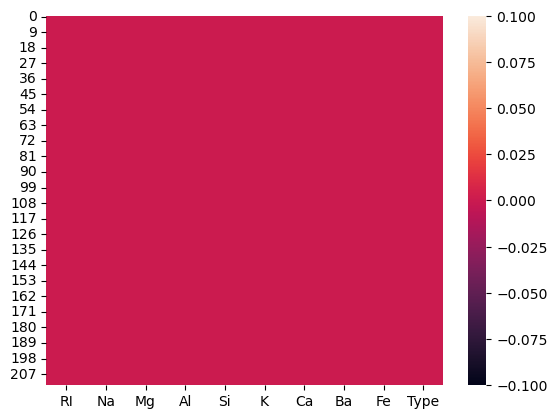

In [110]:
sns.heatmap(df.isnull())

# Visualisasi Data

<Axes: >

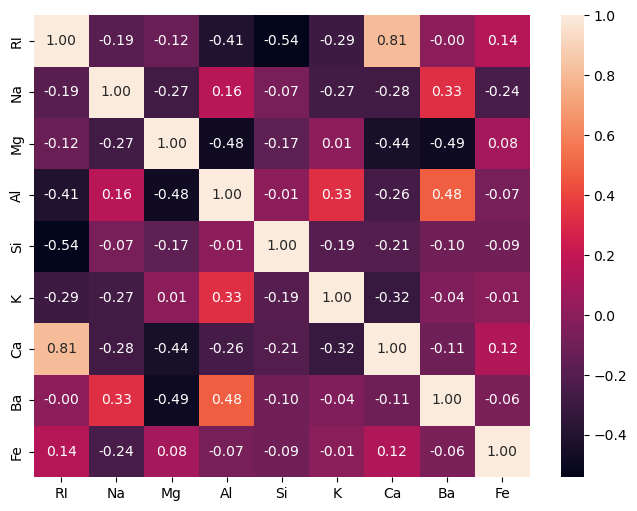

In [111]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('Type', axis=1).corr(), annot=True, fmt='.2f')

# EDA

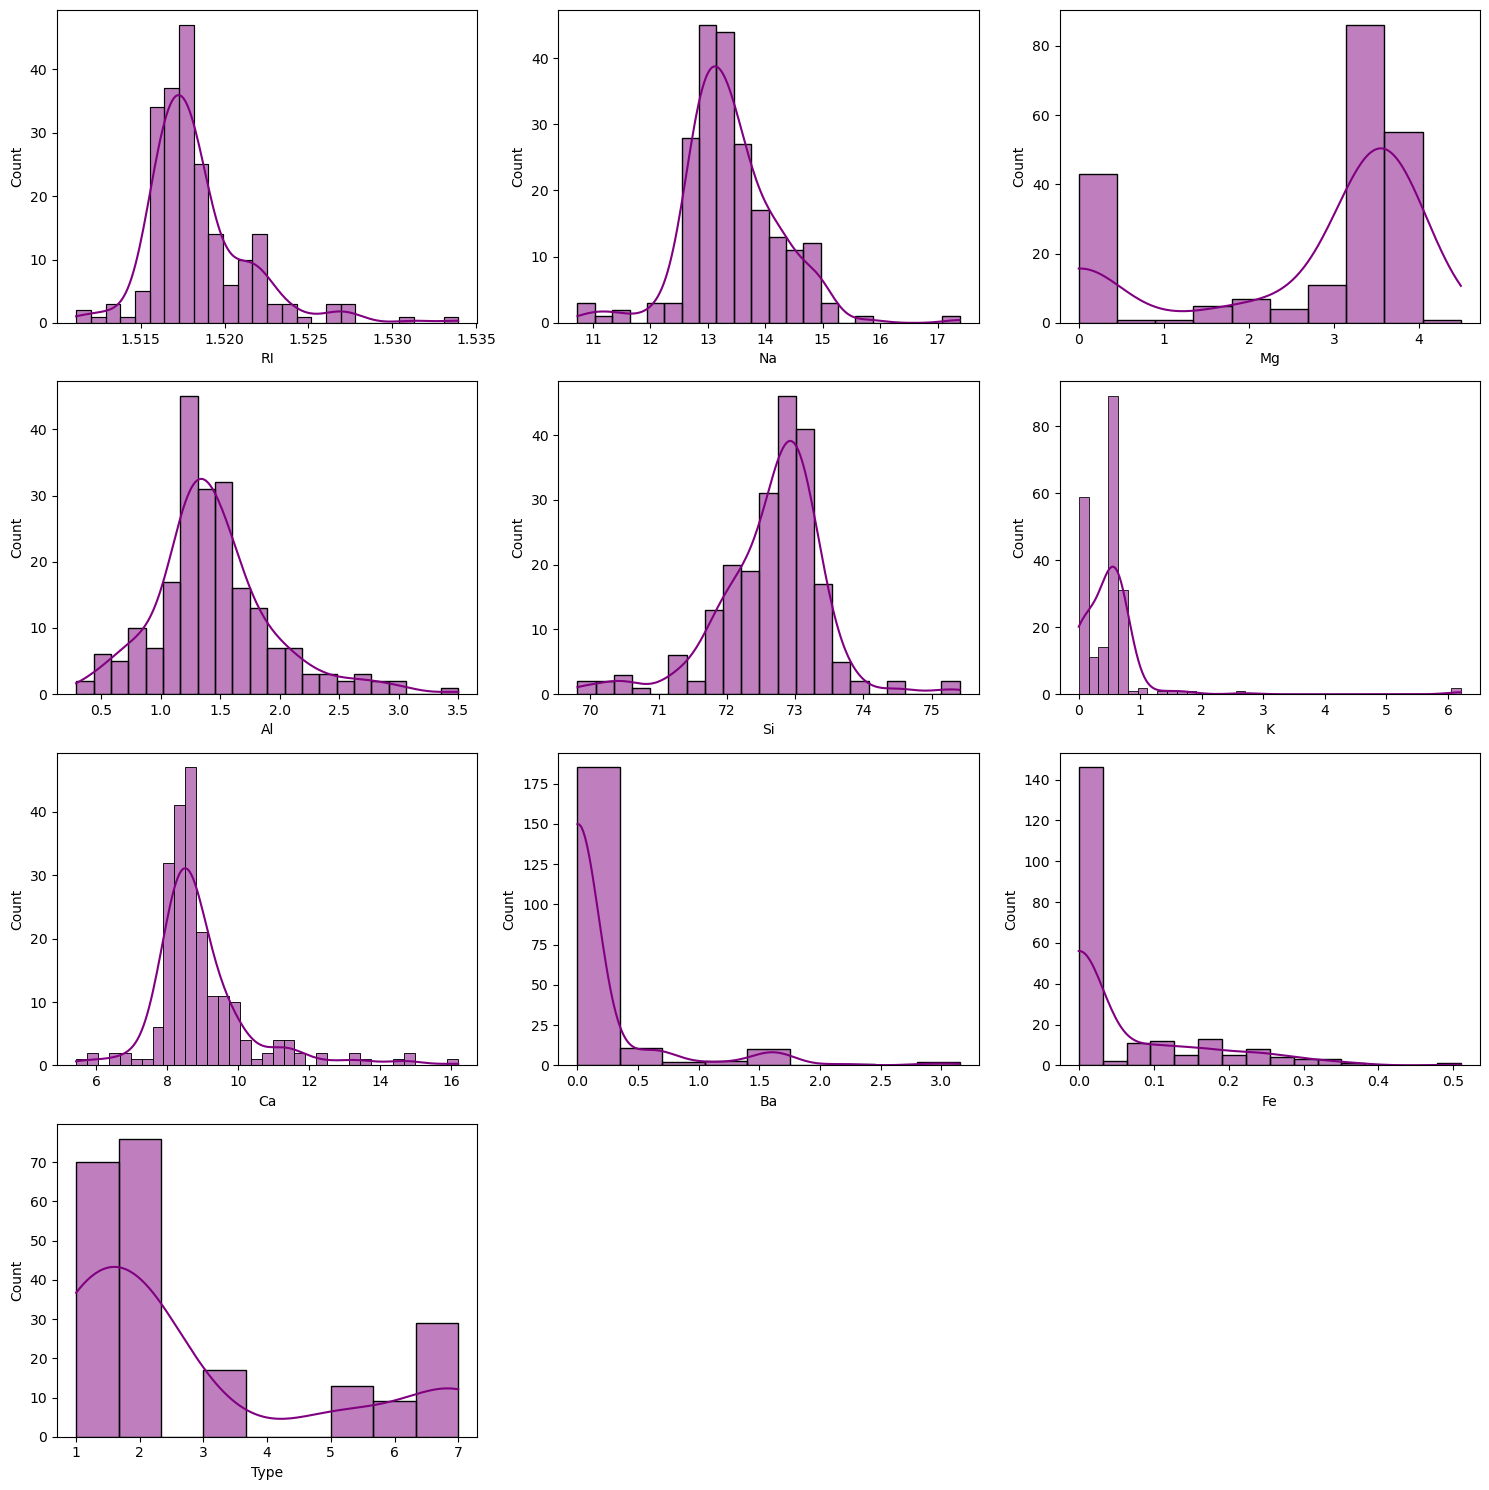

In [112]:
plt.figure(figsize=(15,15))
plotnumber=1
for column in df:
    if plotnumber<=10:
        ax = plt.subplot(4,3,plotnumber)
        sns.histplot(df[column], color = 'purple', kde=True)
        plt.xlabel(column)
    plotnumber+=1
plt.tight_layout()

<Axes: xlabel='Type', ylabel='count'>

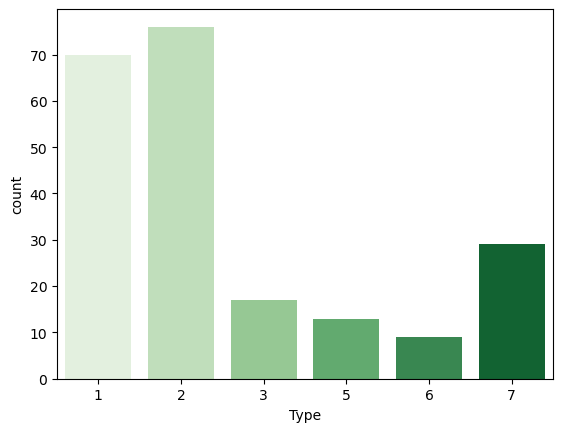

In [113]:
sns.countplot(x='Type', data=df, palette='Greens')

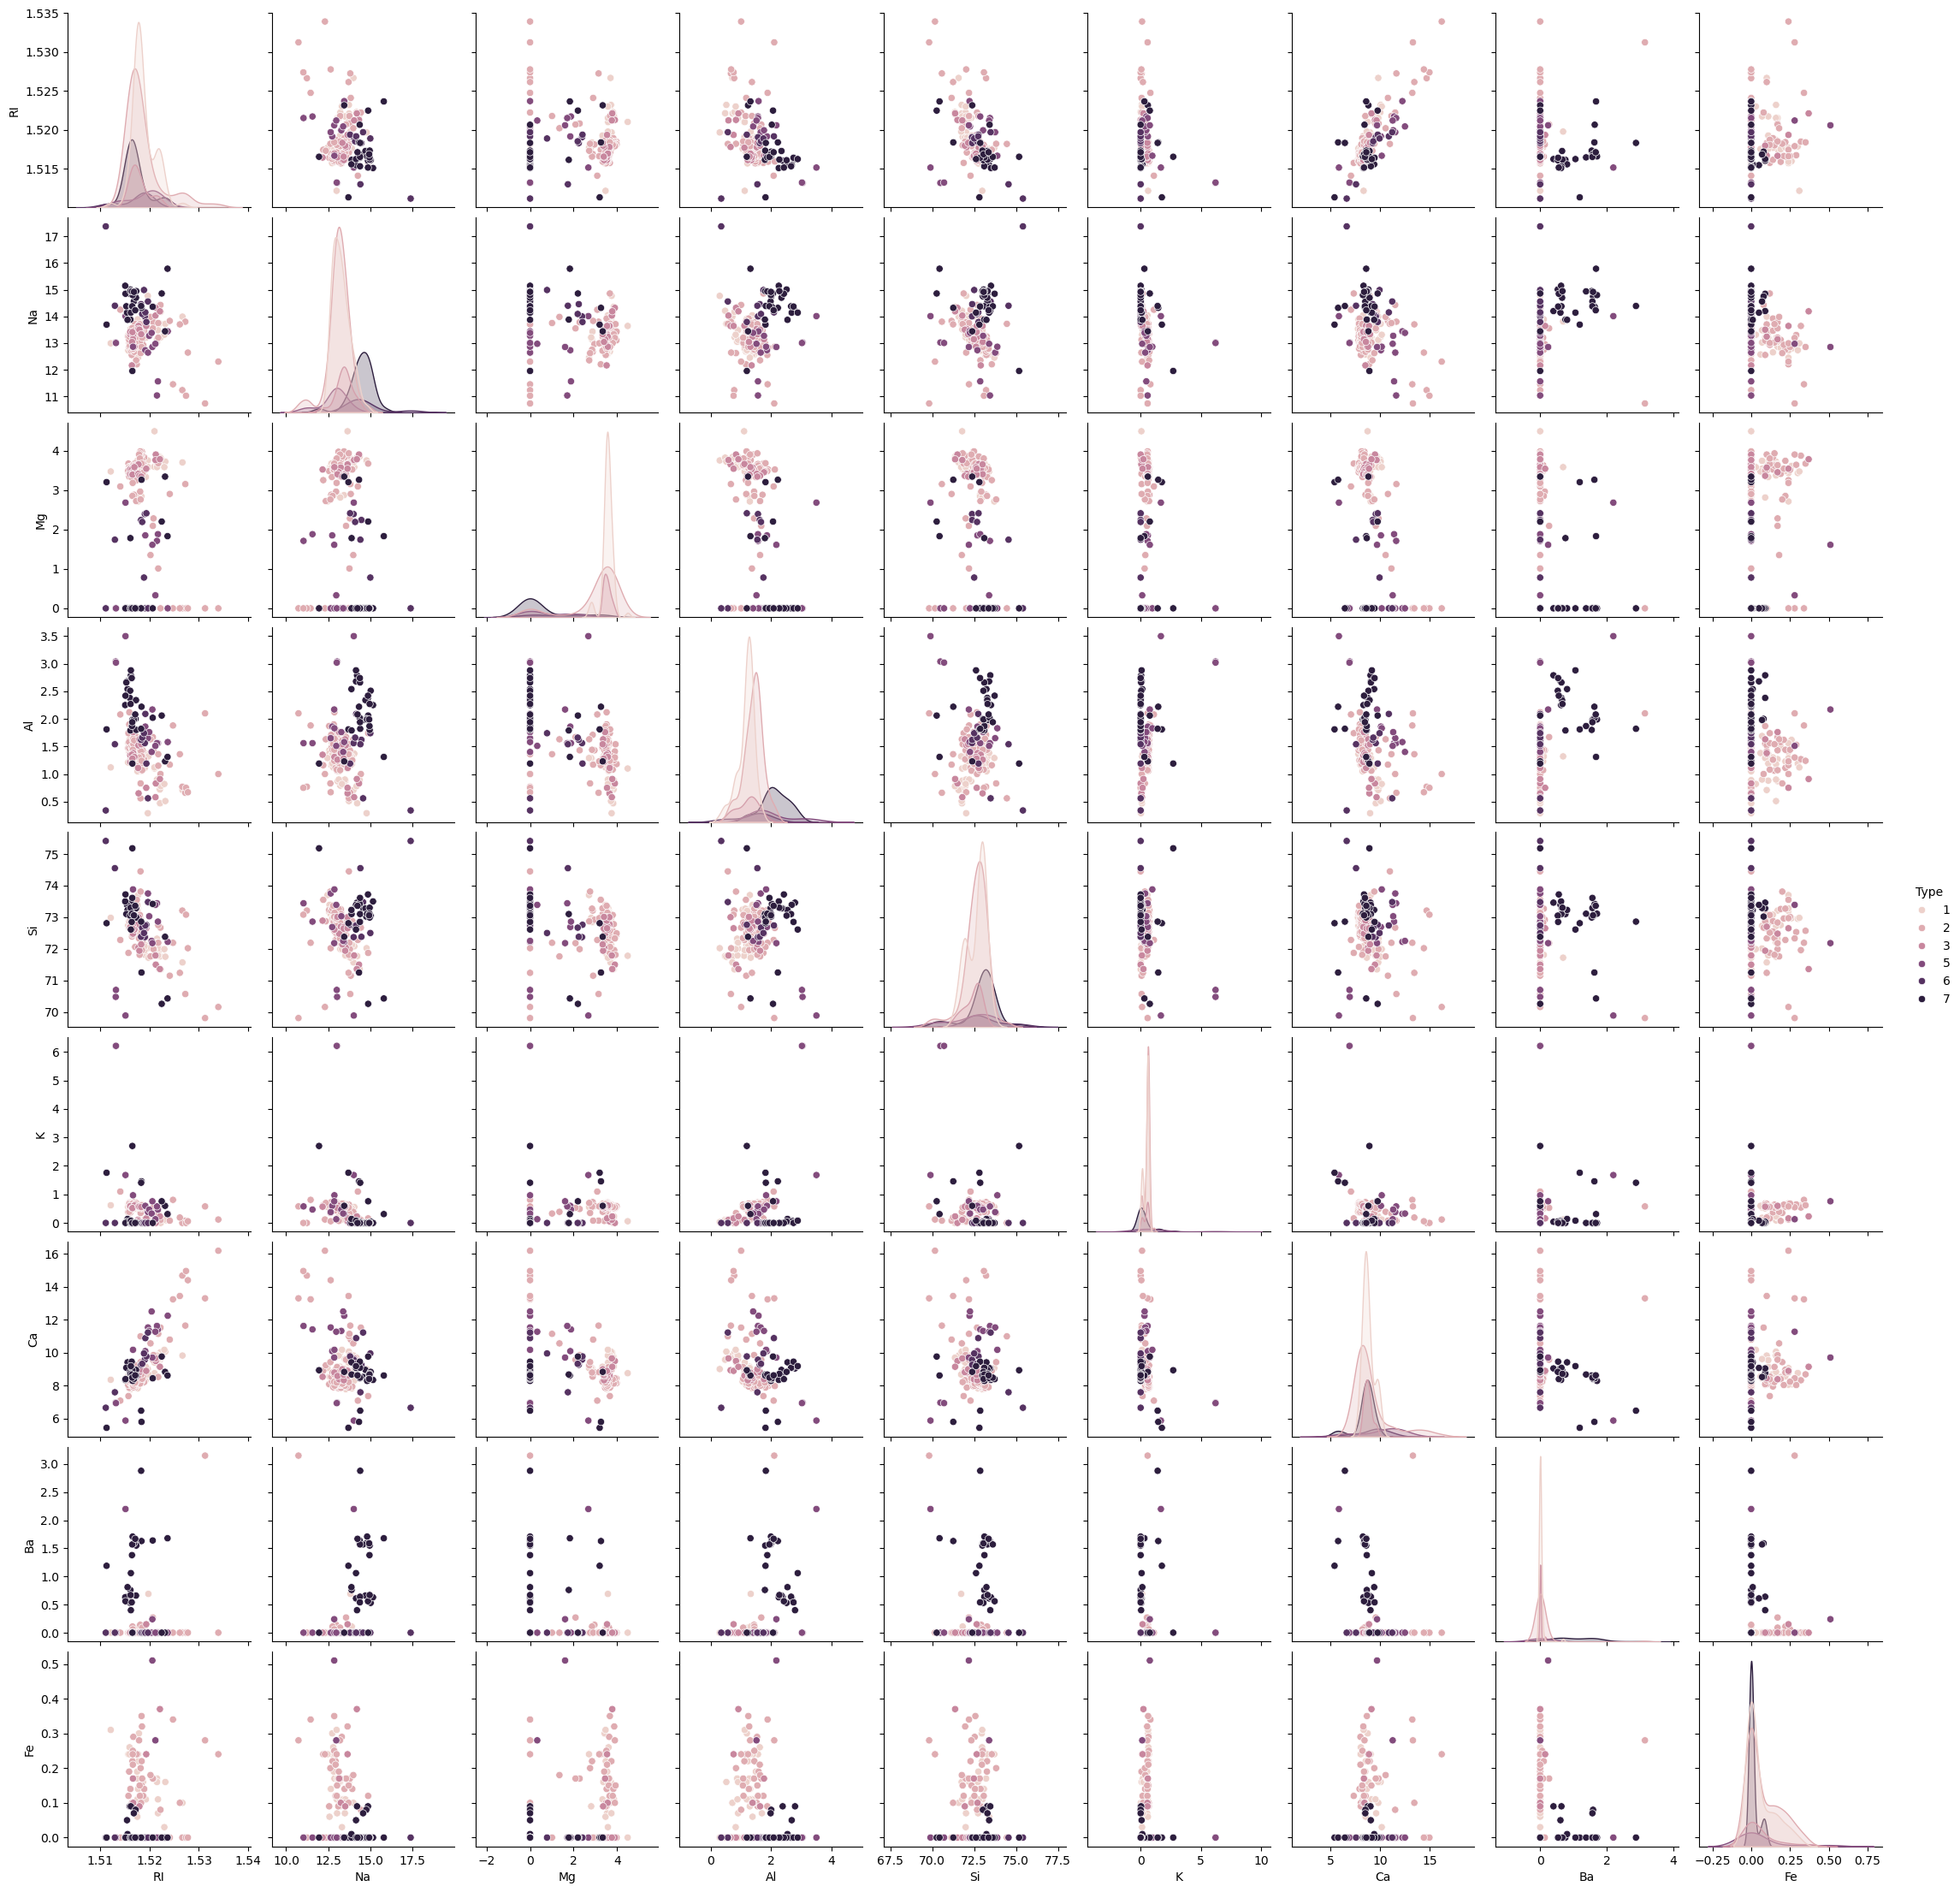

In [114]:
sns.pairplot(df, hue='Type')

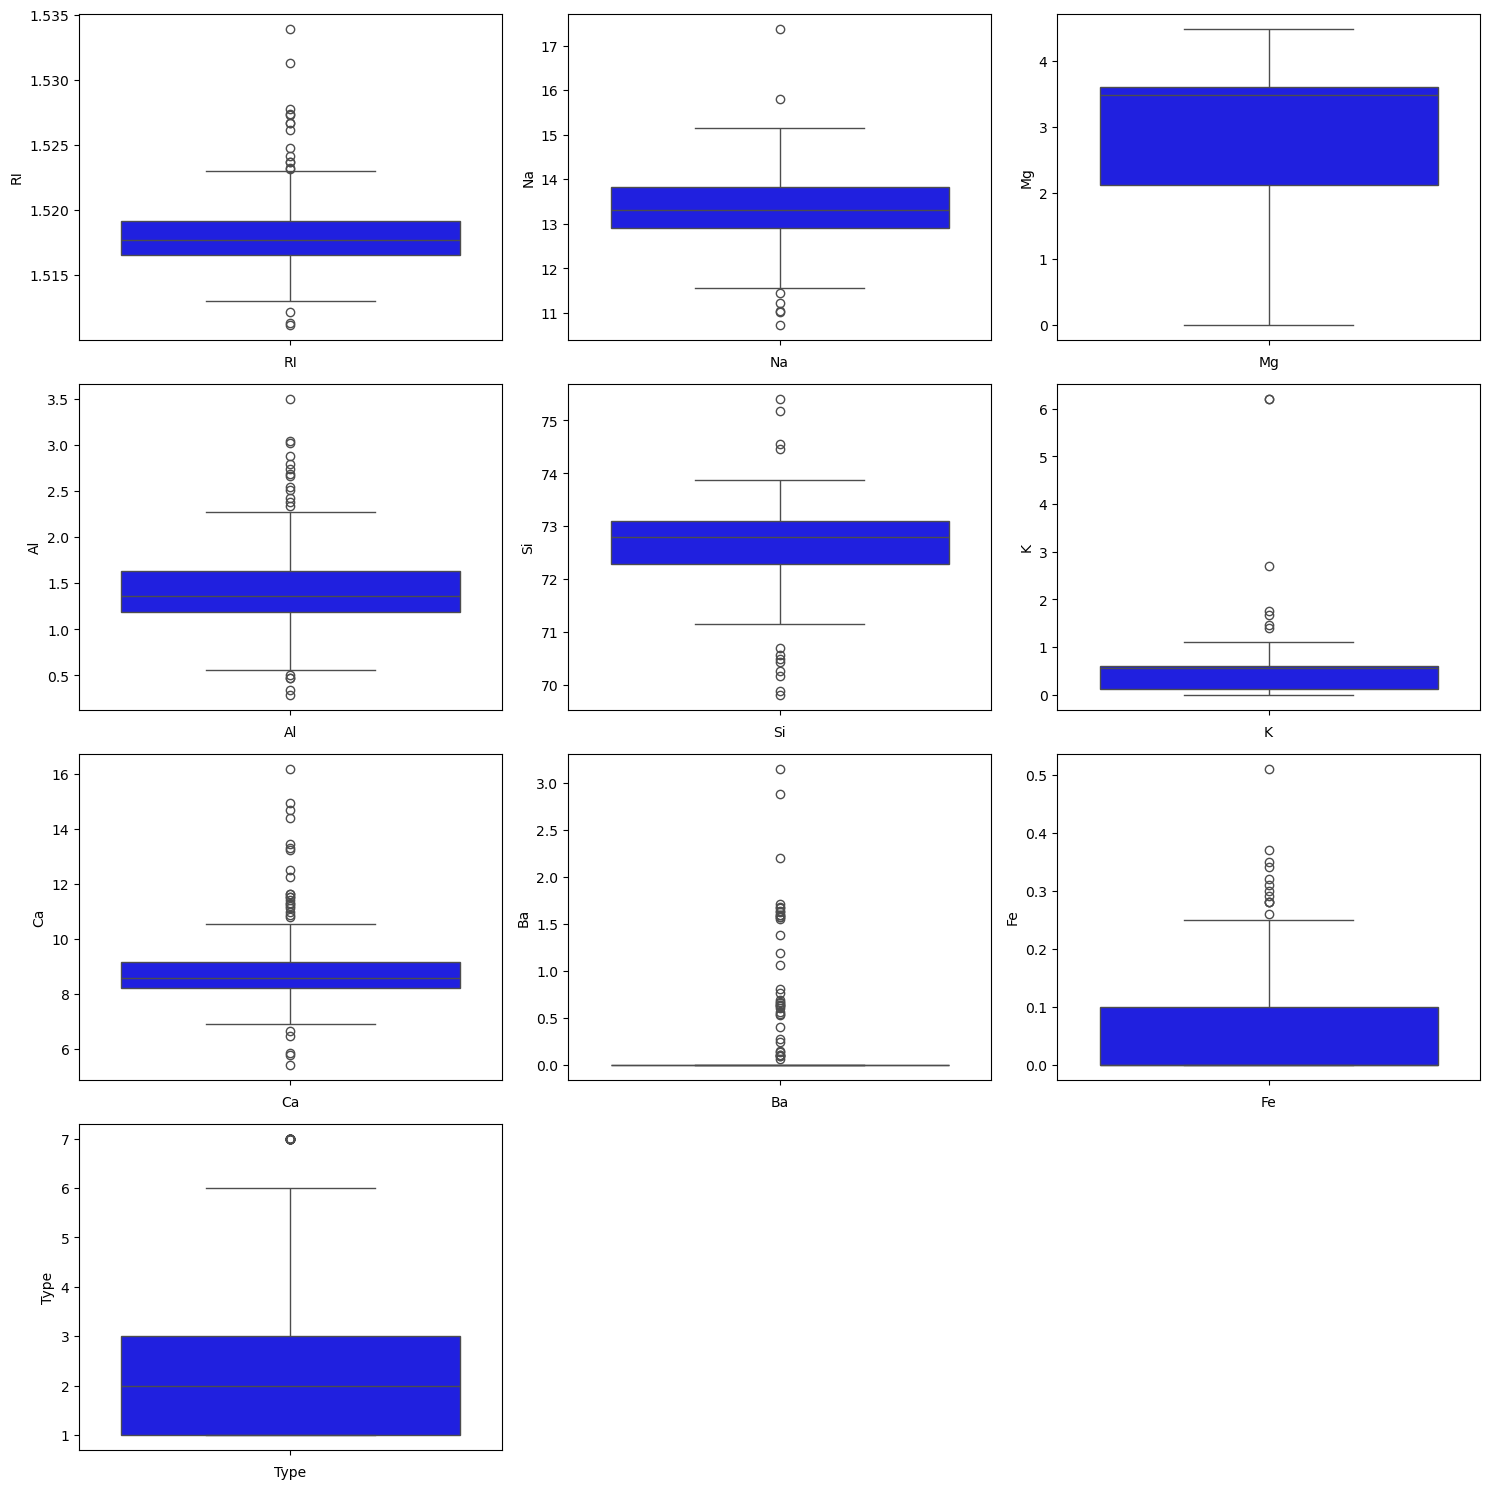

In [115]:
plt.figure(figsize=(15,15))
plotnumber=1
for column in df:
    if plotnumber<=10:
        ax = plt.subplot(4,3,plotnumber)
        sns.boxplot(df[column], color = 'blue')
        plt.xlabel(column)
    plotnumber+=1
plt.tight_layout()

In [116]:
from sklearn.preprocessing import PowerTransformer
col_trans = ['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe']
df1 = df.copy()
pt = PowerTransformer(method='yeo-johnson')
transformed=pt.fit_transform(df1[col_trans])

In [117]:
trans_df = pd.DataFrame(transformed, columns=['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe'])
trans_df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe
0,7.285839e-17,0.317061,1.876273,-0.662630,-1.138642,-1.289781,-0.010654,-0.45489,-0.680015
1,-2.081668e-17,0.616577,0.668163,-0.077498,0.044314,0.274843,-0.884532,-0.45489,-0.680015
2,-5.898060e-17,0.183344,0.608046,0.291075,0.400267,0.018565,-0.938251,-0.45489,-0.680015
3,-1.734723e-17,-0.212585,0.778426,-0.228458,-0.115117,0.501963,-0.488967,-0.45489,-0.680015
4,-2.428613e-17,-0.137547,0.692438,-0.339129,0.526911,0.453753,-0.636365,-0.45489,-0.680015


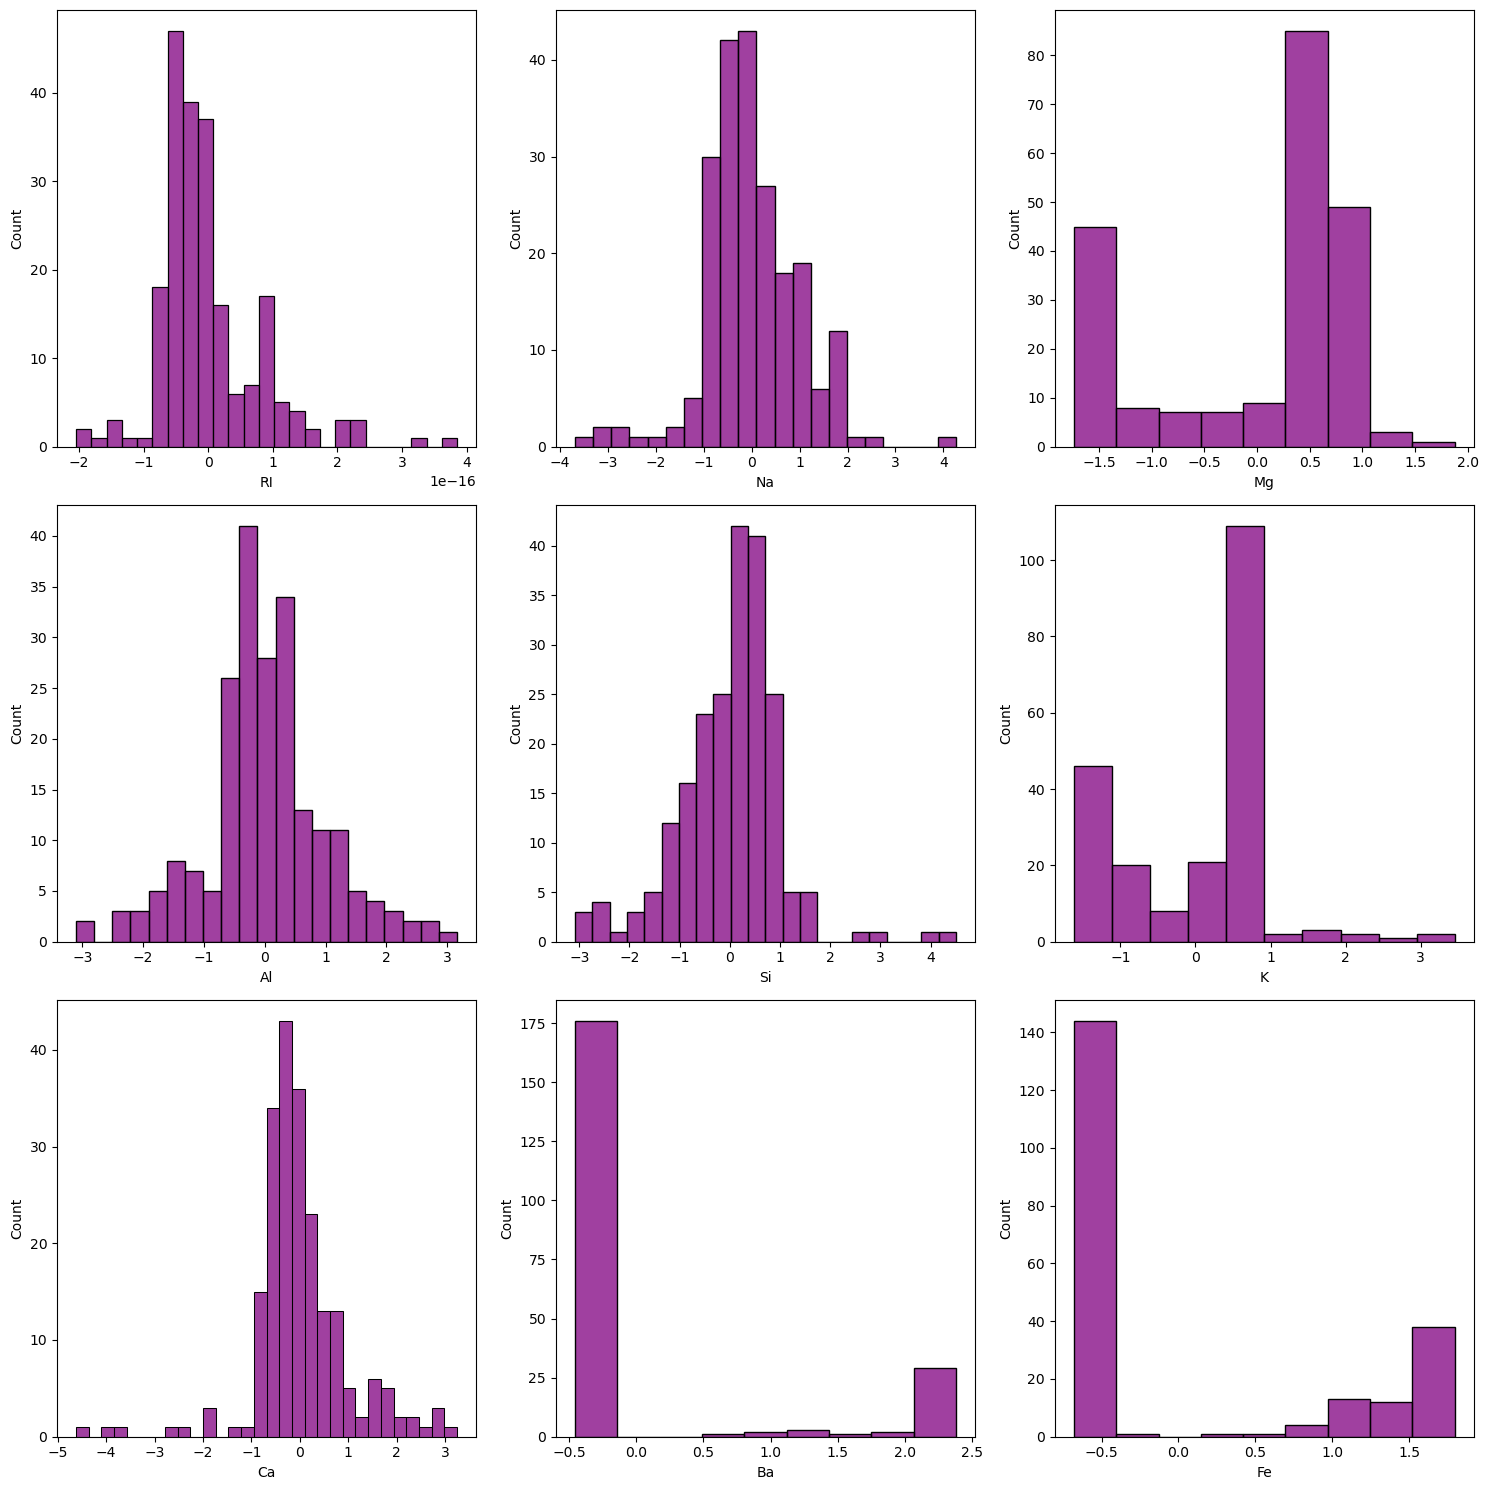

In [118]:
plt.figure(figsize=(15,15))
plotnumber=1
for column in trans_df:
    if plotnumber<=9:
        ax = plt.subplot(3,3,plotnumber)
        sns.histplot(trans_df[column], color = 'purple')
        plt.xlabel(column)
    plotnumber+=1
plt.tight_layout()

# Split and Scaling

In [119]:
X = df.drop('Type', axis=1)
y = df.Type

In [120]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
std_scale = StandardScaler()
X_train_std = std_scale.fit_transform(X_train)
X_test_std = std_scale.transform(X_test)
X_train_scaled = pd.DataFrame(X_train_std, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_std, columns=X.columns)

In [121]:
print(X_train_scaled.shape)

(171, 9)


In [122]:
print(X_test_scaled.shape)

(43, 9)


# Model

In [123]:
knn_class = KNeighborsClassifier()
knn_class.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [124]:
y_pred = knn_class.predict(X_test_scaled)

In [125]:
cm = confusion_matrix(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
ps = precision_score(y_test, y_pred, average='macro')
cr = classification_report(y_test,y_pred)
print('Confusion matrix:\n',cm)
print('----------------------')
print('Accuracy Score:',acc)
print('----------------------')
print('Precision Score:',ps)
print('----------------------')
print('Classification Report:\n',cr)

Confusion matrix:
 [[10  1  0  0  0  0]
 [ 5  8  0  1  0  0]
 [ 1  2  0  0  0  0]
 [ 0  2  0  1  0  1]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]
----------------------
Accuracy Score: 0.6976744186046512
----------------------
Precision Score: 0.6048789173789174
----------------------
Classification Report:
               precision    recall  f1-score   support

           1       0.62      0.91      0.74        11
           2       0.62      0.57      0.59        14
           3       0.00      0.00      0.00         3
           5       0.50      0.25      0.33         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.70        43
   macro avg       0.60      0.62      0.60        43
weighted avg       0.64      0.70      0.66        43



In [126]:
hyperparameter = {'n_neighbors': np.arange(2,15), 'p': [1,2]}
knn_class = KNeighborsClassifier()
grid_cv = GridSearchCV(knn_class, hyperparameter, cv=5)
grid_cv.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14]),
                         'p': [1, 2]})

In [127]:
grid_cv.best_params_

{'n_neighbors': 3, 'p': 1}

In [128]:
grid_cv.best_score_

0.6672268907563026

# input data

In [129]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
pred = lr.predict(X_test)

In [130]:
score = lr.score(X_test, y_test)
print('akurasi model regresi linier =', score)

akurasi model regresi linier = 0.8557278202618005


# imputan model linier

In [131]:
input_df = np.array([[25, 1.517680, 12.907500, 2.115000, 1.190000, 72.28000, 0.122500, 8.240000, 0.00]])

prediction = lr.predict(input_df)
print('Glass Classification:', prediction)

Glass Classification: [3128.52437692]


# save model

In [132]:
import pickle

filename = 'Glass_Classification.sav'
pickle.dump(lr,open(filename,'wb'))